In [1]:
pip install pandas numpy scikit-learn matplotlib

In [1]:
import numpy as np
import  pandas as pd
import  matplotlib as mb

In [3]:
import pandas as pd

data = pd.read_csv("network_data.csv")

data.head()

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.0.106,162.159.135.234,TLSv1.2,172,Application Data
1,2,0.003945,162.159.135.234,192.168.0.106,TCP,54,443 > 1596 [ACK] Seq=1 Ack=119 Win=17 Len=0
2,3,0.296163,162.159.135.234,192.168.0.106,TLSv1.2,88,Application Data
3,4,0.346743,192.168.0.106,162.159.135.234,TCP,54,1596 > 443 [ACK] Seq=119 Ack=35 Win=252 Len=0
4,5,0.853816,192.168.0.106,148.113.9.60,TCP,55,6523 > 443 [ACK] Seq=1 Ack=1 Win=255 Len=1


In [4]:
print(data.columns)

Index(['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info'], dtype='object')


In [5]:
data = data.sample(30000)

In [6]:
print("Total packets:", len(data))

Total packets: 30000


In [7]:
protocol_counts = data["Protocol"].value_counts()

print(protocol_counts)

Protocol
QUIC       15376
TCP         9355
TLSv1.3     4329
DNS          364
TLSv1.2      252
UDP          239
HTTP          54
SSLv2         18
ARP            4
MDNS           4
ICMP           4
IGMPv3         1
Name: count, dtype: int64


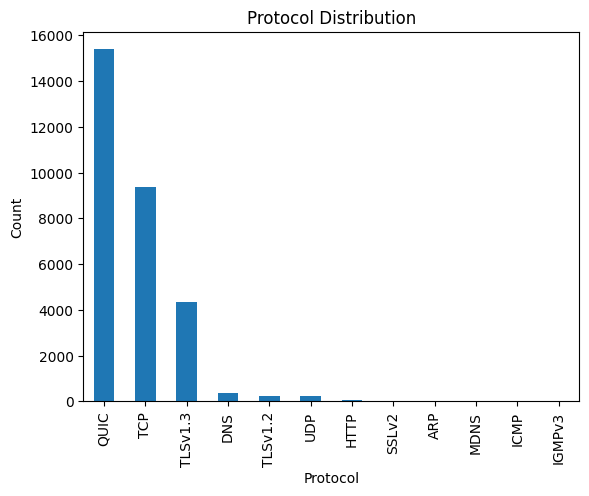

In [8]:
import matplotlib.pyplot as plt

protocol_counts.plot(kind="bar")

plt.title("Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.show()

In [9]:
print("Average Packet Size:", data["Length"].mean())
print("Max Packet Size:", data["Length"].max())

Average Packet Size: 875.3374
Max Packet Size: 1498


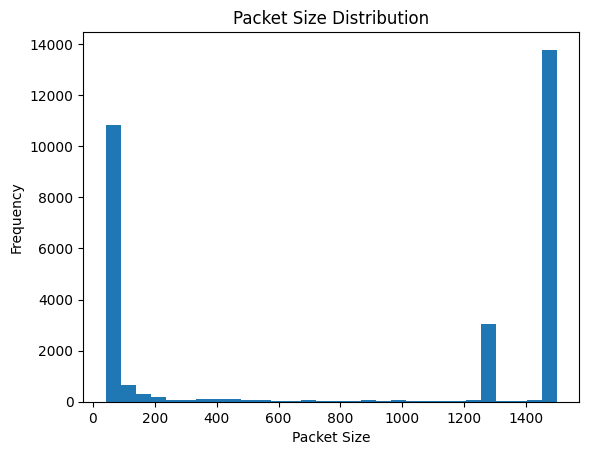

In [10]:
data["Length"].plot(kind="hist", bins=30)

plt.title("Packet Size Distribution")
plt.xlabel("Packet Size")
plt.ylabel("Frequency")

plt.show()

In [11]:
data["Time"] = pd.to_numeric(data["Time"], errors='coerce')
data = data.dropna(subset=["Time"])

In [12]:
data["Time_bin"] = data["Time"].astype(int)

In [13]:
traffic = data.groupby("Time_bin")["Length"].sum()

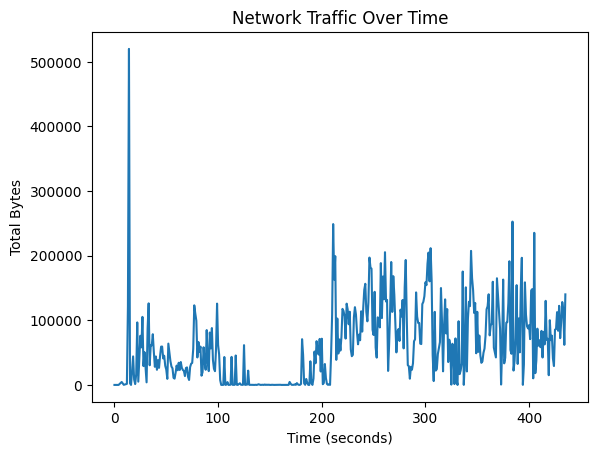

In [14]:
import matplotlib.pyplot as plt

traffic.plot()

plt.title("Network Traffic Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Total Bytes")

plt.show()

In [15]:
threshold = traffic.mean() + 2 * traffic.std()

spikes = traffic[traffic > threshold]

print("Spike points:")
print(spikes)

Spike points:
Time_bin
14     519926
211    248908
213    199278
246    197119
257    188520
261    205390
267    190222
281    193379
302    187454
303    204795
305    211614
344    207402
381    191403
384    252759
393    196756
405    235373
Name: Length, dtype: int64


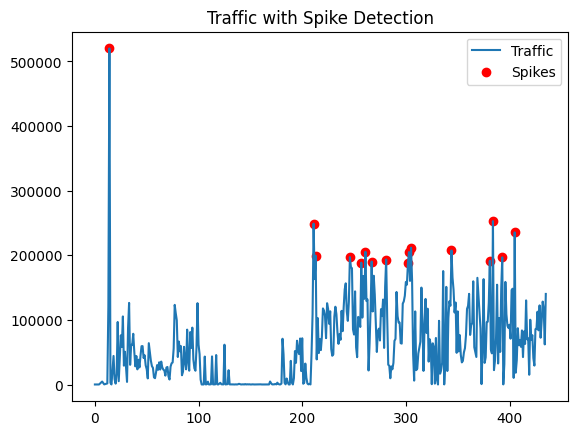

In [16]:
import matplotlib.pyplot as plt

plt.plot(traffic, label="Traffic")
plt.scatter(spikes.index, spikes.values, color='red', label="Spikes")

plt.legend()
plt.title("Traffic with Spike Detection")
plt.show()

In [17]:
import numpy as np

traffic_values = traffic.values

X = []
y = []

for i in range(len(traffic_values) - 1):
    X.append(traffic_values[i])
    y.append(traffic_values[i + 1])

X = np.array(X).reshape(-1, 1)
y = np.array(y)

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [19]:
predictions = model.predict(X)

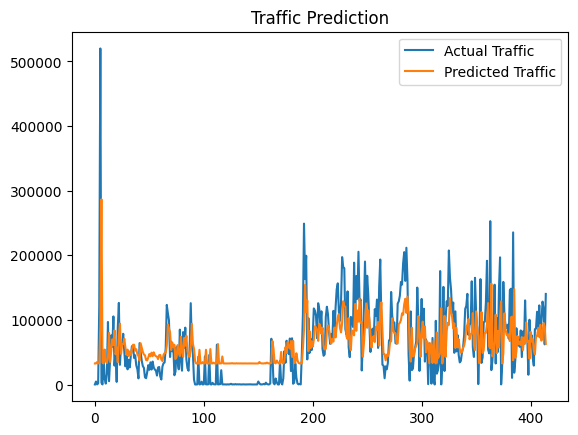

In [20]:
import matplotlib.pyplot as plt

plt.plot(y, label="Actual Traffic")
plt.plot(predictions, label="Predicted Traffic")

plt.legend()
plt.title("Traffic Prediction")

plt.show()

In [36]:
threshold = traffic.mean() + 1 * traffic.std()

for val in predictions:
    if val > threshold:
        print("⚠️ Predicted congestion - take action")

⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action
⚠️ Predicted congestion - take action


In [37]:
alerts = [val for val in predictions if val > threshold]

if len(alerts) > 0:
    print("⚠️ Congestion likely in future traffic!")

⚠️ Congestion likely in future traffic!


In [38]:
!pip install tensorflow

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

traffic_scaled = scaler.fit_transform(traffic.values.reshape(-1, 1))

In [40]:
import numpy as np

X = []
y = []

window_size = 20

for i in range(len(traffic_scaled) - window_size):
    X.append(traffic_scaled[i:i+window_size])
    y.append(traffic_scaled[i+window_size])

X = np.array(X)
y = np.array(y)

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [43]:
model.fit(X, y, epochs=30, batch_size=32)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.0114
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0082
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0078
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0076
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0077
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0076
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0078
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0078
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0080
Epoch 10/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0076
Epoch 11/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0075
Epoch 12/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0074
Epoch 13/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0074
Epoch 14/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0072
Epoch 15/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0073
Epoc

In [44]:
predictions = model.predict(X)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


In [45]:
predictions = scaler.inverse_transform(predictions)
y_actual = scaler.inverse_transform(y)

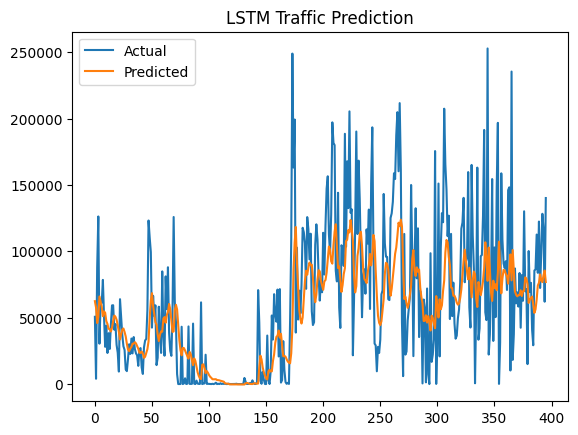

In [46]:
import matplotlib.pyplot as plt

plt.plot(y_actual, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("LSTM Traffic Prediction")

plt.show()

In [51]:
threshold = traffic.mean() + 1 * traffic.std()

alerts = []

for val in predictions:
    if val > threshold:
        alerts.append(val)

if len(alerts) > 0:
    print("⚠️ Future congestion predicted!")
else:
    print("✅ Network is stable")

⚠️ Future congestion predicted!


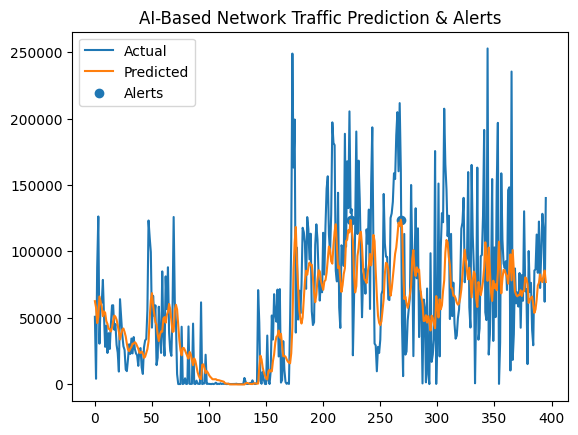

In [52]:
import matplotlib.pyplot as plt

plt.plot(y_actual, label="Actual")
plt.plot(predictions, label="Predicted")

# highlight alerts
alert_indices = [i for i, val in enumerate(predictions) if val > threshold]

plt.scatter(alert_indices, predictions[alert_indices], label="Alerts")

plt.legend()
plt.title("AI-Based Network Traffic Prediction & Alerts")

plt.show()

In [53]:
if len(alerts) > 5:
    print("🚨 High congestion risk - Allocate more bandwidth")
elif len(alerts) > 0:
    print("⚠️ Moderate congestion - Monitor network")
else:
    print("✅ Network running normally")

⚠️ Moderate congestion - Monitor network


In [54]:
print(traffic.mean())
print(traffic.std())
print("Threshold:", threshold)

63125.293269230766
60148.07086640377
Threshold: 123273.36413563453
